In [1]:
from pathlib import Path

# Change this only if your notebook is somewhere else
DATA_ROOT = Path("../data")

print("Data root:", DATA_ROOT.resolve())

subjects = sorted(DATA_ROOT.glob("SBJ*"))

print("Number of subjects:", len(subjects))

for subject in subjects:
    print(subject.name)

Data root: E:\IIT KGP IEEE\data
Number of subjects: 15
SBJ01
SBJ02
SBJ03
SBJ04
SBJ05
SBJ06
SBJ07
SBJ08
SBJ09
SBJ10
SBJ11
SBJ12
SBJ13
SBJ14
SBJ15


In [2]:
subject = DATA_ROOT / "SBJ01"

print("Subject:", subject)

for session in sorted(subject.glob("S*")):
    print(session)

Subject: ..\data\SBJ01
..\data\SBJ01\S01
..\data\SBJ01\S02
..\data\SBJ01\S03
..\data\SBJ01\S04
..\data\SBJ01\S05
..\data\SBJ01\S06
..\data\SBJ01\S07


In [3]:
session = subject / "S01"

print("Session contents:")

for item in session.iterdir():
    print(item.name)

Session contents:
Test
Train


In [4]:
train_dir = session / "Train"

for item in train_dir.iterdir():
    print(item.name)

trainData.mat
trainEvents.txt
trainLabels.txt
trainTargets.txt


In [5]:
import numpy as np
from scipy.io import loadmat

In [6]:
mat_file = train_dir / "trainData.mat"

mat = loadmat(mat_file)

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'trainData'])


In [7]:
data_variables = {
    key: value
    for key, value in mat.items()
    if not key.startswith("__")
}

for key, value in data_variables.items():
    print(key, value.shape)

trainData (8, 350, 1600)


In [8]:
eeg = list(data_variables.values())[0]

print("Original shape:", eeg.shape)

Original shape: (8, 350, 1600)


Train folder: E:\IIT KGP IEEE\data\SBJ01\S01\Train

MATLAB variables:
trainData (8, 350, 1600)

Original EEG shape: (8, 350, 1600)
Reorganized EEG shape: (1600, 8, 350)

Events shape: (1600,)
Targets shape: (1600,)
Labels shape: (20,)

BLOCK 1
EEG shape: (80, 8, 350)
Expected: (80, 8, 350)

Target object: 6

Number of target events: 10
Number of non-target events: 70

RUN STRUCTURE
Run  1 | Epochs  1- 8 | Objects: [7, 3, 4, 1, 6, 2, 8, 5] | Targets: [0, 0, 0, 0, 1, 0, 0, 0]
Run  2 | Epochs  9-16 | Objects: [2, 5, 4, 6, 1, 3, 8, 7] | Targets: [0, 0, 0, 1, 0, 0, 0, 0]
Run  3 | Epochs 17-24 | Objects: [8, 5, 1, 2, 4, 7, 6, 3] | Targets: [0, 0, 0, 0, 0, 0, 1, 0]
Run  4 | Epochs 25-32 | Objects: [8, 5, 7, 6, 2, 3, 1, 4] | Targets: [0, 0, 0, 1, 0, 0, 0, 0]
Run  5 | Epochs 33-40 | Objects: [2, 1, 7, 6, 5, 3, 4, 8] | Targets: [0, 0, 0, 1, 0, 0, 0, 0]
Run  6 | Epochs 41-48 | Objects: [2, 8, 4, 6, 1, 5, 7, 3] | Targets: [0, 0, 0, 1, 0, 0, 0, 0]
Run  7 | Epochs 49-56 | Objects: [5, 1, 8, 4, 3, 7,

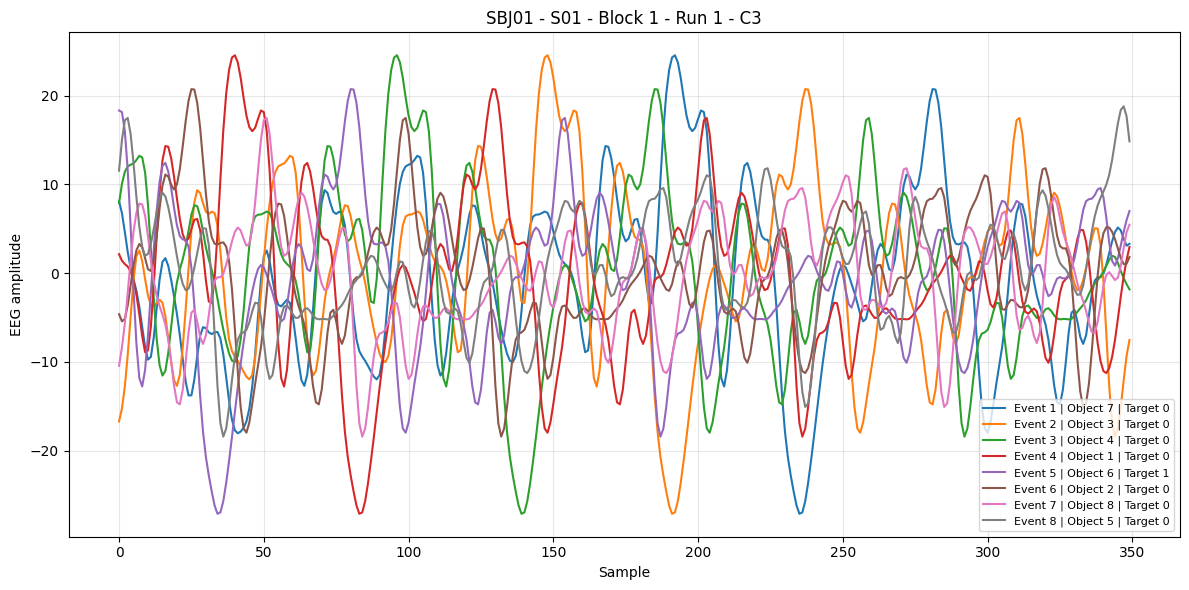

In [ ]:


from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# 1. DATA LOCATION


DATA_ROOT = Path("../data")


subject = "SBJ01"
session = "S01"

train_dir = DATA_ROOT / subject / session / "Train"

print("Train folder:", train_dir.resolve())


# ------------------------------------------------------------
# 2. LOAD EEG DATA
# ------------------------------------------------------------

mat_file = train_dir / "trainData.mat"

mat = loadmat(mat_file)

# Find the actual MATLAB data variable
data_variables = {
    key: value
    for key, value in mat.items()
    if not key.startswith("__")
}

print("\nMATLAB variables:")
for key, value in data_variables.items():
    print(key, value.shape)

# Get EEG array
eeg = list(data_variables.values())[0]

print("\nOriginal EEG shape:", eeg.shape)



X = np.transpose(eeg, (2, 0, 1))

print("Reorganized EEG shape:", X.shape)


# ------------------------------------------------------------
# 4. LOAD EVENTS
# ------------------------------------------------------------

events_file = train_dir / "trainEvents.txt"

events = np.loadtxt(
    events_file,
    dtype=int
).flatten()

print("\nEvents shape:", events.shape)


# ------------------------------------------------------------
# 5. LOAD TARGETS
# ------------------------------------------------------------

targets_file = train_dir / "trainTargets.txt"

targets = np.loadtxt(
    targets_file,
    dtype=int
).flatten()

print("Targets shape:", targets.shape)


# ------------------------------------------------------------
# 6. LOAD BLOCK LABELS
# ------------------------------------------------------------

labels_file = train_dir / "trainLabels.txt"

labels = np.loadtxt(
    labels_file,
    dtype=int
).flatten()

print("Labels shape:", labels.shape)


# ------------------------------------------------------------
# 7. EXTRACT BLOCK 1
#
# Training:
# 10 runs × 8 events = 80 epochs per block
# ------------------------------------------------------------

BLOCK_SIZE = 10 * 8

block_1 = X[0:BLOCK_SIZE]

block_1_events = events[0:BLOCK_SIZE]

block_1_targets = targets[0:BLOCK_SIZE]

block_1_label = labels[0]


# ------------------------------------------------------------
# 8. BLOCK 1 INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BLOCK 1")
print("=" * 60)

print("EEG shape:", block_1.shape)
print("Expected: (80, 8, 350)")

print("\nTarget object:", block_1_label)

print("\nNumber of target events:",
      np.sum(block_1_targets == 1))

print("Number of non-target events:",
      np.sum(block_1_targets == 0))



# 9. SHOW EACH RUN


print("\n" + "=" * 60)
print("RUN STRUCTURE")
print("=" * 60)

for run in range(10):

    start = run * 8
    end = start + 8

    print(
        f"Run {run + 1:2d} | "
        f"Epochs {start + 1:2d}-{end:2d} | "
        f"Objects: {block_1_events[start:end].tolist()} | "
        f"Targets: {block_1_targets[start:end].tolist()}"
    )


# ------------------------------------------------------------
# 10. PLOT THE 8 EVENTS OF RUN 1
#     Channel 0 = C3
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

for event in range(8):

    plt.plot(
        block_1[event, 0, :],
        label=(
            f"Event {event + 1} | "
            f"Object {block_1_events[event]} | "
            f"Target {block_1_targets[event]}"
        )
    )

plt.xlabel("Sample")
plt.ylabel("EEG amplitude")
plt.title("SBJ01 - S01 - Block 1 - Run 1 - C3")

plt.legend(fontsize=8)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

EEG shape: (80, 8, 350)

MATLAB variables and their types:
trainData type = <class 'numpy.ndarray'> shape = (8, 350, 1600)

First epoch shape: (8, 350)

First epoch statistics:
 C3: min=-27.117, max=24.546, mean=-0.603, std=9.824
 Cz: min=-33.025, max=28.413, mean=-0.779, std=10.567
 C4: min=-21.355, max=23.411, mean=-1.164, std=9.373
CPz: min=-27.652, max=32.637, mean=-0.777, std=10.664
 P3: min=-22.374, max=29.840, mean=-0.652, std=9.374
 Pz: min=-24.025, max=31.180, mean=-0.687, std=10.073
 P4: min=-21.249, max=26.354, mean=-0.982, std=8.759
POz: min=-22.418, max=29.489, mean=-0.687, std=9.221


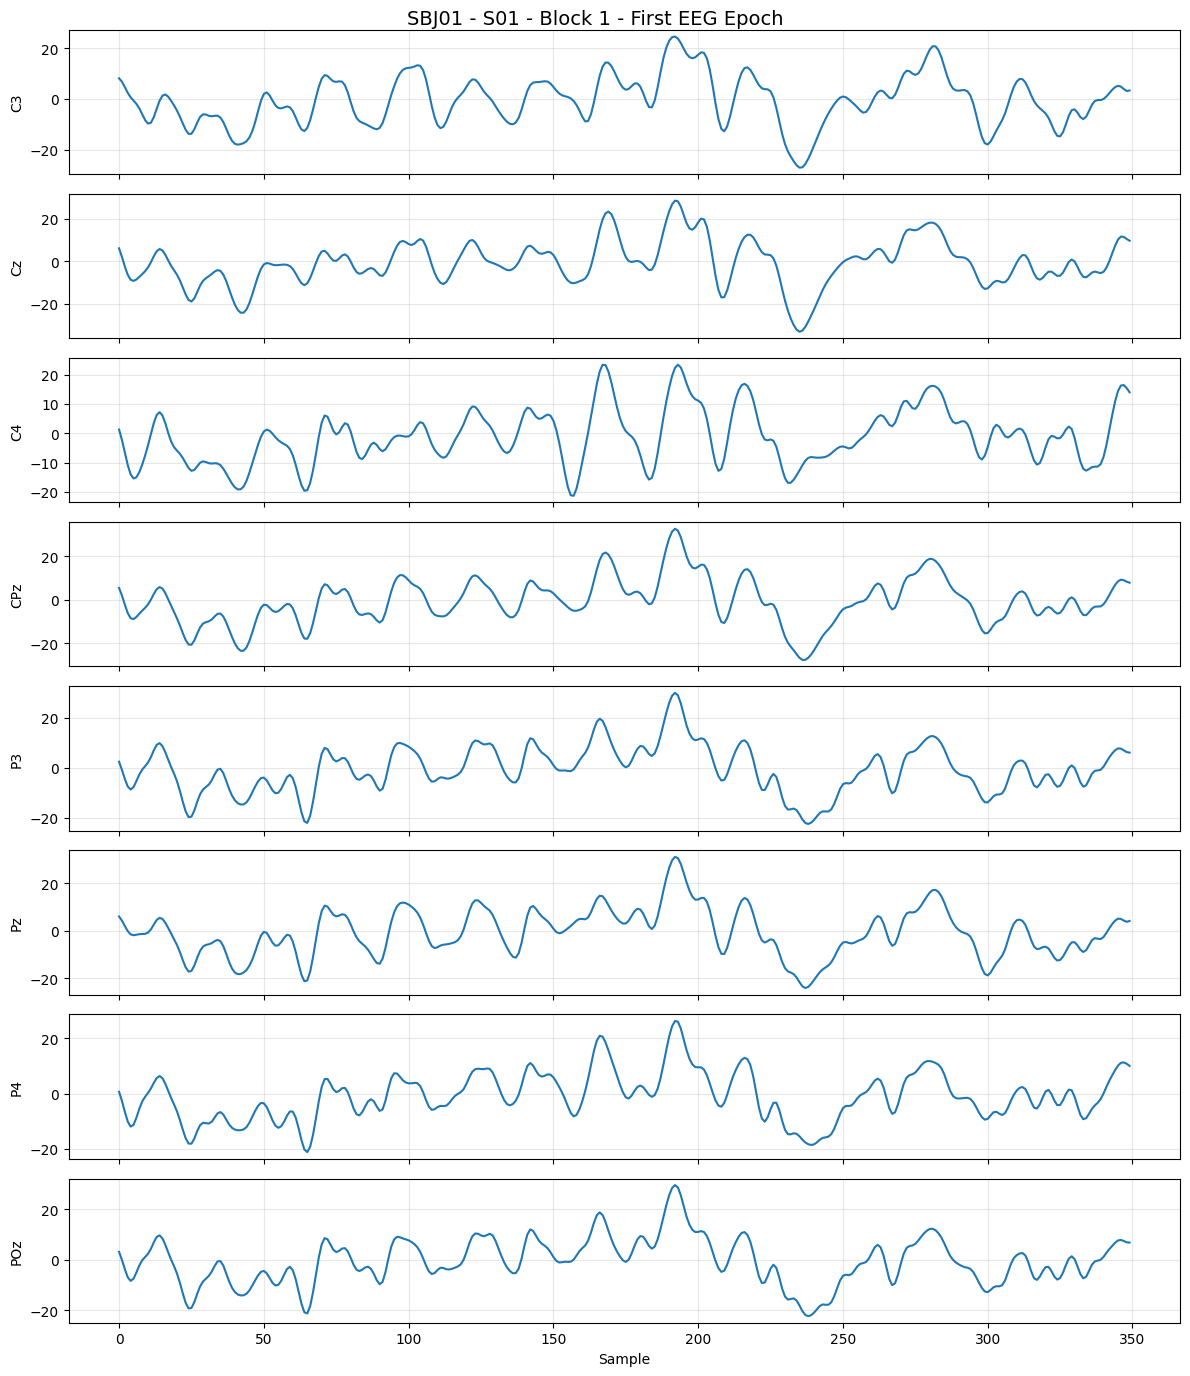

In [14]:
# ============================================================
# STEP 2 — INSPECT THE 350-SAMPLE EPOCH
# ============================================================

print("EEG shape:", block_1.shape)

# ------------------------------------------------------------
# Check sampling frequency from MATLAB file
# ------------------------------------------------------------

print("\nMATLAB variables and their types:")

for key, value in mat.items():
    if not key.startswith("__"):
        print(
            key,
            "type =", type(value),
            "shape =", getattr(value, "shape", None)
        )

# ------------------------------------------------------------
# Inspect the first epoch
# ------------------------------------------------------------

epoch = block_1[0]          # First event
channel_names = ["C3", "Cz", "C4", "CPz", "P3", "Pz", "P4", "POz"]

print("\nFirst epoch shape:", epoch.shape)

print("\nFirst epoch statistics:")

for ch in range(8):
    print(
        f"{channel_names[ch]:>3}: "
        f"min={epoch[ch].min():.3f}, "
        f"max={epoch[ch].max():.3f}, "
        f"mean={epoch[ch].mean():.3f}, "
        f"std={epoch[ch].std():.3f}"
    )

# ------------------------------------------------------------
# Plot all 8 channels of the first epoch
# ------------------------------------------------------------

fig, axes = plt.subplots(8, 1, figsize=(12, 14), sharex=True)

for ch in range(8):
    axes[ch].plot(epoch[ch])
    axes[ch].set_ylabel(channel_names[ch])
    axes[ch].grid(True, alpha=0.3)

axes[-1].set_xlabel("Sample")
fig.suptitle(
    "SBJ01 - S01 - Block 1 - First EEG Epoch",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Preprocessing

Block 1
  ↓
Raw EEG
  ↓
Band-pass filter
  ↓
Baseline correction (-200 to 0 ms)
  ↓
Channel-wise normalization
  ↓
Compare before vs after

Time range:
-200 ms → 1196 ms

Raw Block 1 shape: (80, 8, 350)
After filtering: (80, 8, 350)

Number of baseline samples: 50
After baseline correction: (80, 8, 350)
After normalization: (80, 8, 350)

Checking normalized data:
 C3: mean=0.0000, std=1.0000
 Cz: mean=-0.0000, std=1.0000
 C4: mean=-0.0000, std=1.0000
CPz: mean=0.0000, std=1.0000
 P3: mean=-0.0000, std=1.0000
 Pz: mean=0.0000, std=1.0000
 P4: mean=-0.0000, std=1.0000
POz: mean=-0.0000, std=1.0000

First target epoch: 4
First non-target epoch: 0


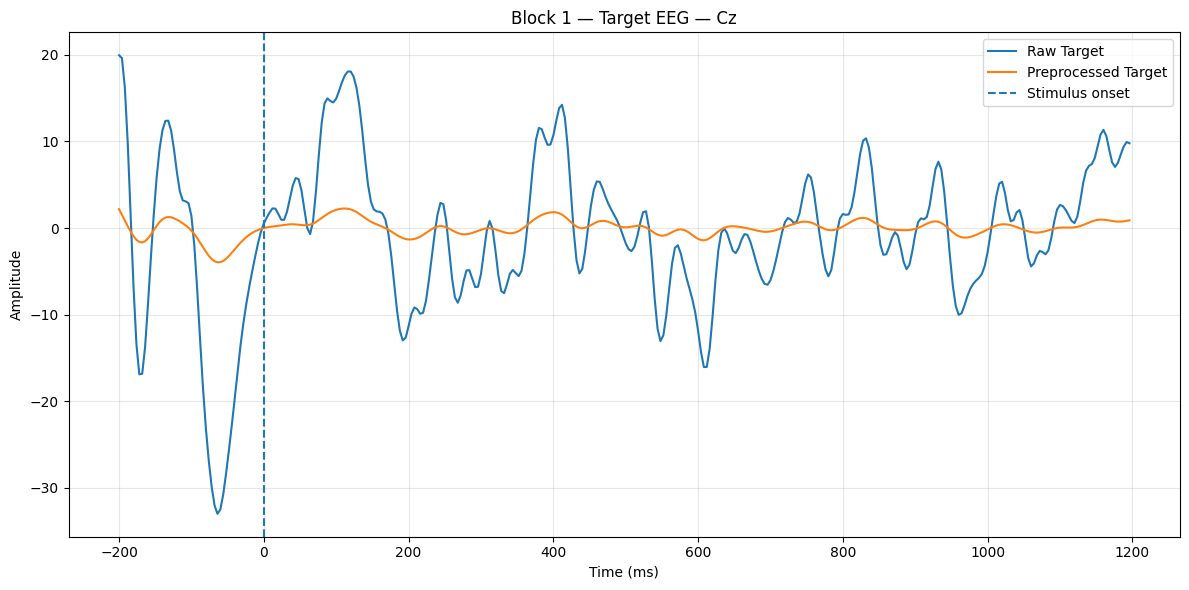

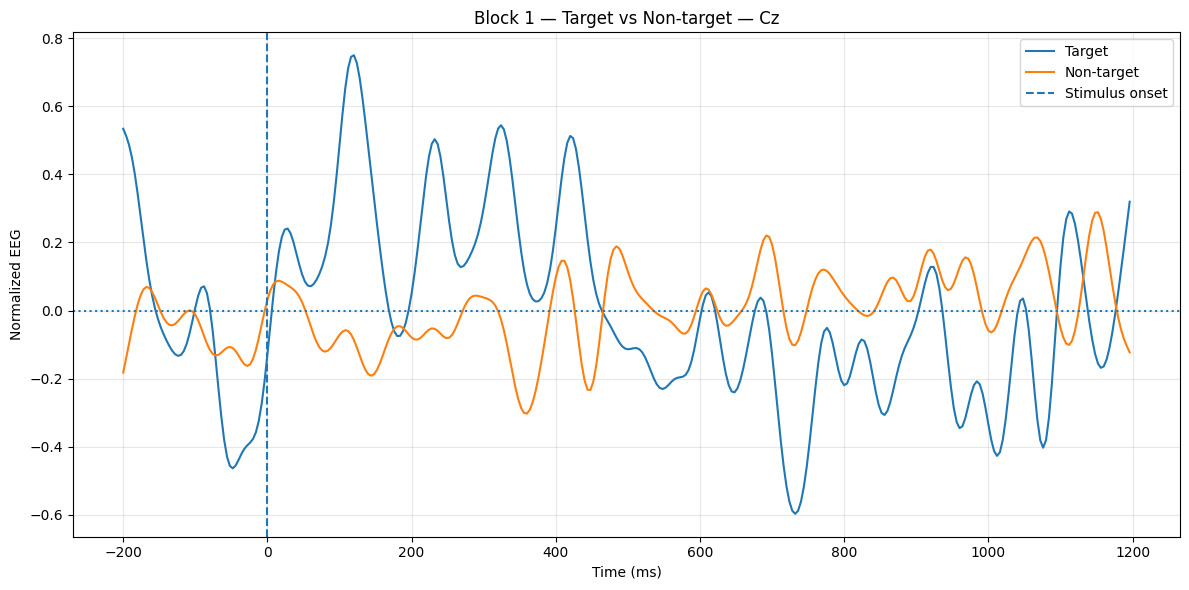


PHASE 1 PREPROCESSING COMPLETE
X_phase1 shape: (80, 8, 350)
y_phase1 shape: (80,)

X_phase1 = preprocessed EEG
Shape = (epochs, channels, samples)

y_phase1 = target/non-target

Target: 10
Non-target: 70


In [15]:
# ============================================================
# PHASE 1.2 — P300 PREPROCESSING
# SBJ01 / S01 / BLOCK 1
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# ------------------------------------------------------------
# 1. PARAMETERS
# ------------------------------------------------------------

FS = 250                    # Sampling frequency
LOWCUT = 0.1                # High-pass frequency (Hz)
HIGHCUT = 20.0              # Low-pass frequency (Hz)

channel_names = [
    "C3", "Cz", "C4", "CPz",
    "P3", "Pz", "P4", "POz"
]

# Time axis:
# -200 ms to +1200 ms
time = np.arange(350) / FS - 0.200

print("Time range:")
print(f"{time[0]*1000:.0f} ms → {time[-1]*1000:.0f} ms")


# ------------------------------------------------------------
# 2. COPY RAW BLOCK 1
# ------------------------------------------------------------

X_raw = block_1.copy()

print("\nRaw Block 1 shape:", X_raw.shape)


# ------------------------------------------------------------
# 3. BAND-PASS FILTER
# ------------------------------------------------------------

def bandpass_filter(data, lowcut, highcut, fs, order=4):

    nyquist = fs / 2

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype="band"
    )

    filtered = filtfilt(
        b,
        a,
        data,
        axis=-1
    )

    return filtered


X_filtered = bandpass_filter(
    X_raw,
    LOWCUT,
    HIGHCUT,
    FS
)

print("After filtering:", X_filtered.shape)


# ------------------------------------------------------------
# 4. BASELINE CORRECTION
#
# Baseline = -200 ms to 0 ms
#
# At 250 Hz:
# -200 ms = sample 0
# 0 ms    = sample 50
# ------------------------------------------------------------

baseline_samples = time < 0

print(
    "\nNumber of baseline samples:",
    np.sum(baseline_samples)
)

baseline_mean = X_filtered[:, :, baseline_samples].mean(
    axis=2,
    keepdims=True
)

X_baseline = X_filtered - baseline_mean

print("After baseline correction:", X_baseline.shape)


# ------------------------------------------------------------
# 5. CHANNEL-WISE Z-SCORE NORMALIZATION
# ------------------------------------------------------------

channel_mean = X_baseline.mean(
    axis=2,
    keepdims=True
)

channel_std = X_baseline.std(
    axis=2,
    keepdims=True
)

X_preprocessed = (
    X_baseline - channel_mean
) / (channel_std + 1e-8)

print(
    "After normalization:",
    X_preprocessed.shape
)


# ------------------------------------------------------------
# 6. CHECK MEAN / STD
# ------------------------------------------------------------

print("\nChecking normalized data:")

for ch in range(8):

    mean_value = X_preprocessed[:, ch, :].mean()
    std_value = X_preprocessed[:, ch, :].std()

    print(
        f"{channel_names[ch]:>3}: "
        f"mean={mean_value:.4f}, "
        f"std={std_value:.4f}"
    )


# ------------------------------------------------------------
# 7. PLOT ONE TARGET AND ONE NON-TARGET
#
# Find first target and first non-target event
# ------------------------------------------------------------

target_idx = np.where(block_1_targets == 1)[0][0]
non_target_idx = np.where(block_1_targets == 0)[0][0]

print("\nFirst target epoch:", target_idx)
print("First non-target epoch:", non_target_idx)


# ------------------------------------------------------------
# 8. PLOT Cz
# ------------------------------------------------------------

cz = 1

plt.figure(figsize=(12, 6))

plt.plot(
    time * 1000,
    X_raw[target_idx, cz, :],
    label="Raw Target"
)

plt.plot(
    time * 1000,
    X_preprocessed[target_idx, cz, :],
    label="Preprocessed Target"
)

plt.axvline(
    0,
    linestyle="--",
    label="Stimulus onset"
)

plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.title("Block 1 — Target EEG — Cz")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. TARGET VS NON-TARGET AVERAGE
# ------------------------------------------------------------

target_average = X_preprocessed[
    block_1_targets == 1
].mean(axis=0)

non_target_average = X_preprocessed[
    block_1_targets == 0
].mean(axis=0)


plt.figure(figsize=(12, 6))

plt.plot(
    time * 1000,
    target_average[cz],
    label="Target"
)

plt.plot(
    time * 1000,
    non_target_average[cz],
    label="Non-target"
)

plt.axvline(
    0,
    linestyle="--",
    label="Stimulus onset"
)

plt.axhline(
    0,
    linestyle=":"
)

plt.xlabel("Time (ms)")
plt.ylabel("Normalized EEG")
plt.title("Block 1 — Target vs Non-target — Cz")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. FINAL PHASE-1 OUTPUT
# ------------------------------------------------------------

X_phase1 = X_preprocessed
y_phase1 = block_1_targets.copy()

print("\n" + "=" * 60)
print("PHASE 1 PREPROCESSING COMPLETE")
print("=" * 60)

print("X_phase1 shape:", X_phase1.shape)
print("y_phase1 shape:", y_phase1.shape)

print(
    "\nX_phase1 = preprocessed EEG"
    "\nShape = (epochs, channels, samples)"
)

print(
    "\ny_phase1 = target/non-target"
)

print("\nTarget:", np.sum(y_phase1 == 1))
print("Non-target:", np.sum(y_phase1 == 0))

Input EEG shape: (80, 8, 350)

Spike-time shape: (80, 8)
Expected: (80 epochs, 8 channels)

========== FIRST EEG EPOCH ==========
 C3 : spike time = 0.9112 s
 Cz : spike time = 0.9317 s
 C4 : spike time = 1.0000 s
CPz : spike time = 0.0158 s
 P3 : spike time = 0.0106 s
 Pz : spike time = 0.1003 s
 P4 : spike time = 0.5067 s
POz : spike time = 0.0000 s


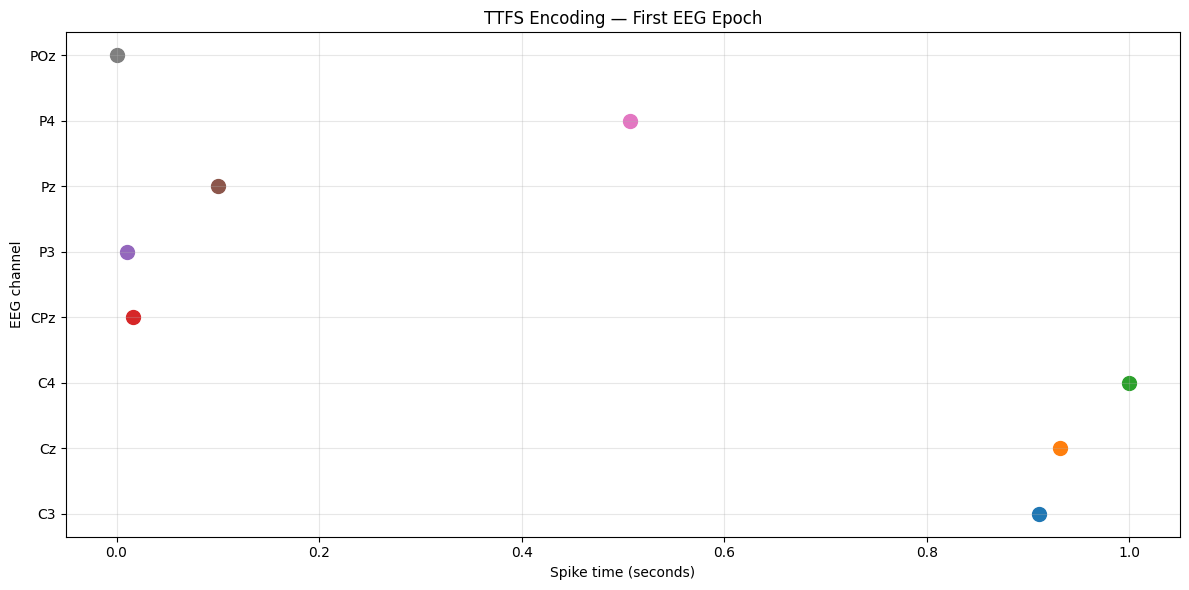


Spike train shape: (80, 8, 100)
Expected: (80 epochs, 8 channels, 100 time steps)

Total spikes: 640
Expected approximately: 640


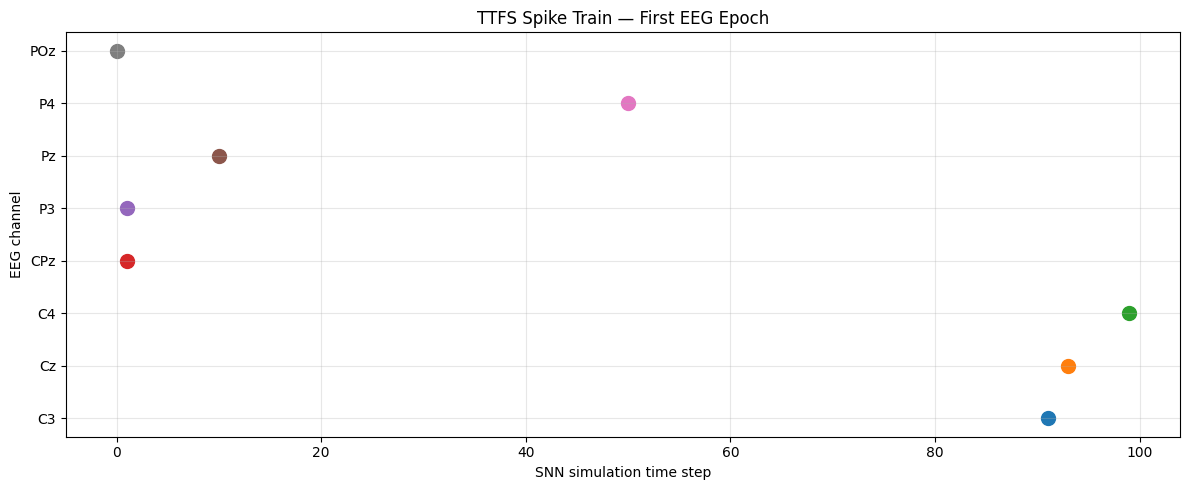


PHASE 2 — TTFS ENCODING COMPLETE
EEG input:        (80, 8, 350)
Spike times:      (80, 8)
Spike train:      (80, 8, 100)
Labels:           (80,)

Pipeline:
Preprocessed EEG → TTFS → Spike Times → Spike Train

Ready for Phase 3: Adaptive-LIF SNN


In [16]:
# ============================================================
# PHASE 2 — TEMPORAL SPIKE ENCODING
# TTFS (TIME-TO-FIRST-SPIKE)
# SBJ01 / S01 / BLOCK 1
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. INPUT
# ------------------------------------------------------------

# X_phase1:
# (epochs, channels, samples)
#
# Block 1:
# (80, 8, 350)

print("Input EEG shape:", X_phase1.shape)


# ------------------------------------------------------------
# 2. TTFS ENCODING
#
# Principle:
#
# Stronger EEG value → earlier spike
# Weaker EEG value → later spike
#
# Each channel produces ONE spike.
# ------------------------------------------------------------

def ttfs_encode(X, min_time=0.0, max_time=1.0):
    """
    Time-to-First-Spike encoding.

    Input:
        X = (epochs, channels, samples)

    Output:
        spike_times = (epochs, channels)

    Each channel gets one spike time.
    """

    # --------------------------------------------------------
    # Use maximum activation across the EEG time dimension.
    # --------------------------------------------------------

    activation = np.max(X, axis=2)

    # --------------------------------------------------------
    # Normalize each epoch across its 8 channels
    # to [0, 1].
    # --------------------------------------------------------

    min_val = activation.min(axis=1, keepdims=True)
    max_val = activation.max(axis=1, keepdims=True)

    normalized = (
        activation - min_val
    ) / (
        max_val - min_val + 1e-8
    )

    # --------------------------------------------------------
    # Convert activation → spike time.
    #
    # activation = 1 → min_time
    # activation = 0 → max_time
    # --------------------------------------------------------

    spike_times = (
        max_time
        - normalized * (max_time - min_time)
    )

    return spike_times


# ------------------------------------------------------------
# 3. ENCODE BLOCK 1
# ------------------------------------------------------------

spike_times = ttfs_encode(X_phase1)

print("\nSpike-time shape:", spike_times.shape)

print(
    "Expected:",
    "(80 epochs, 8 channels)"
)


# ------------------------------------------------------------
# 4. DISPLAY FIRST EPOCH
# ------------------------------------------------------------

channel_names = [
    "C3", "Cz", "C4", "CPz",
    "P3", "Pz", "P4", "POz"
]

print("\n========== FIRST EEG EPOCH ==========")

for ch in range(8):

    print(
        f"{channel_names[ch]:>3} : "
        f"spike time = "
        f"{spike_times[0, ch]:.4f} s"
    )


# ------------------------------------------------------------
# 5. VISUALIZE SPIKE TIMES
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

for ch in range(8):

    plt.scatter(
        spike_times[0, ch],
        ch,
        s=100
    )

plt.yticks(
    range(8),
    channel_names
)

plt.xlabel("Spike time (seconds)")
plt.ylabel("EEG channel")

plt.title(
    "TTFS Encoding — First EEG Epoch"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. CONVERT SPIKE TIMES TO DISCRETE SPIKE TRAIN
#
# The SNN needs temporal spikes.
#
# Here we create a 100-step simulation window.
# ------------------------------------------------------------

N_STEPS = 100

dt = 1.0 / N_STEPS

spike_train = np.zeros(
    (
        X_phase1.shape[0],   # epochs
        X_phase1.shape[1],   # channels
        N_STEPS              # time steps
    ),
    dtype=np.float32
)


# ------------------------------------------------------------
# Convert spike time → spike index
# ------------------------------------------------------------

spike_indices = (
    spike_times * N_STEPS
).astype(int)

spike_indices = np.clip(
    spike_indices,
    0,
    N_STEPS - 1
)


# ------------------------------------------------------------
# Put a 1 at the spike time
# ------------------------------------------------------------

for epoch in range(X_phase1.shape[0]):

    for channel in range(X_phase1.shape[1]):

        t = spike_indices[epoch, channel]

        spike_train[
            epoch,
            channel,
            t
        ] = 1.0


# ------------------------------------------------------------
# 7. CHECK SPIKE TRAIN
# ------------------------------------------------------------

print(
    "\nSpike train shape:",
    spike_train.shape
)

print(
    "Expected:",
    "(80 epochs, 8 channels, 100 time steps)"
)


# ------------------------------------------------------------
# 8. COUNT SPIKES
# ------------------------------------------------------------

print(
    "\nTotal spikes:",
    int(spike_train.sum())
)

print(
    "Expected approximately:",
    80 * 8
)


# ------------------------------------------------------------
# 9. VISUALIZE SPIKE TRAIN OF FIRST EPOCH
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

for ch in range(8):

    spike_positions = np.where(
        spike_train[0, ch, :] == 1
    )[0]

    plt.scatter(
        spike_positions,
        np.full_like(
            spike_positions,
            ch
        ),
        s=100
    )

plt.yticks(
    range(8),
    channel_names
)

plt.xlabel("SNN simulation time step")
plt.ylabel("EEG channel")

plt.title(
    "TTFS Spike Train — First EEG Epoch"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. FINAL PHASE 2 OUTPUT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PHASE 2 — TTFS ENCODING COMPLETE")
print("=" * 60)

print("EEG input:       ", X_phase1.shape)
print("Spike times:     ", spike_times.shape)
print("Spike train:     ", spike_train.shape)
print("Labels:          ", y_phase1.shape)

print(
    "\nPipeline:"
)

print(
    "Preprocessed EEG"
    " → TTFS"
    " → Spike Times"
    " → Spike Train"
)

print(
    "\nReady for Phase 3:"
    " Adaptive-LIF SNN"
)

Spike train shape: (80, 8, 350)
Labels shape: (80,)

SNN parameters:
Input neurons : 8
Hidden neurons: 32
Output neurons: 2
Time steps    : 350

Weight shapes:
Input → Hidden : (8, 32)
Hidden → Output: (32, 2)

FIRST EPOCH
True label: 0
Predicted class: 0
Output spike counts: [0. 0.]


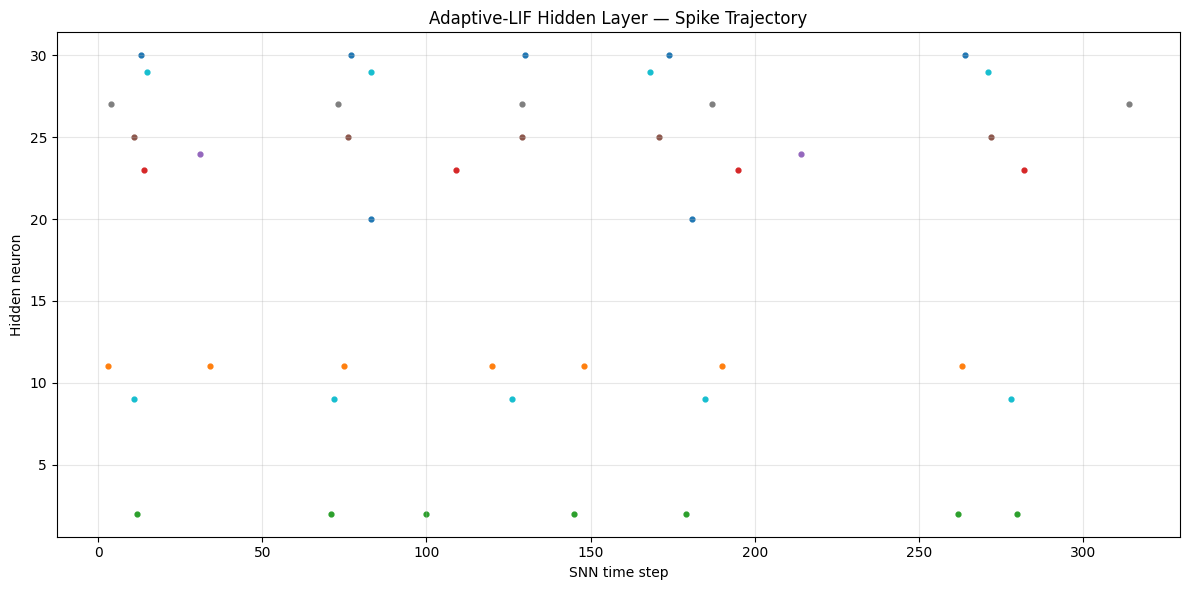

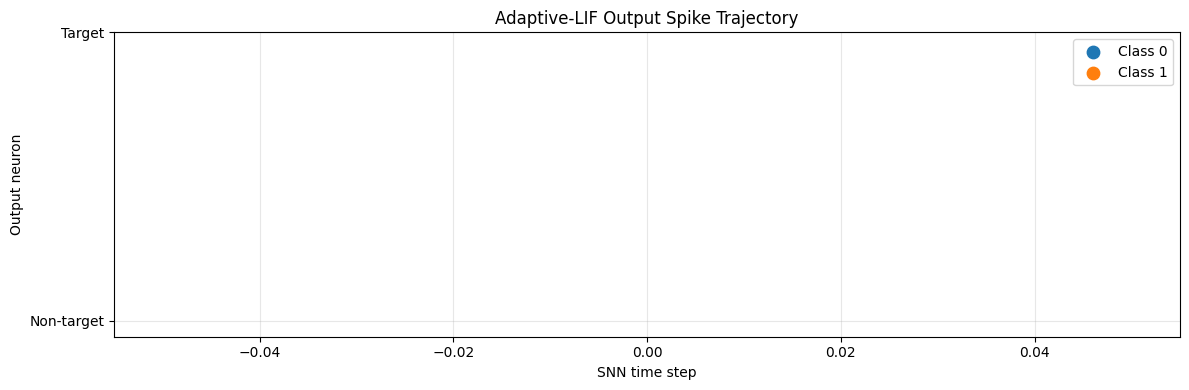

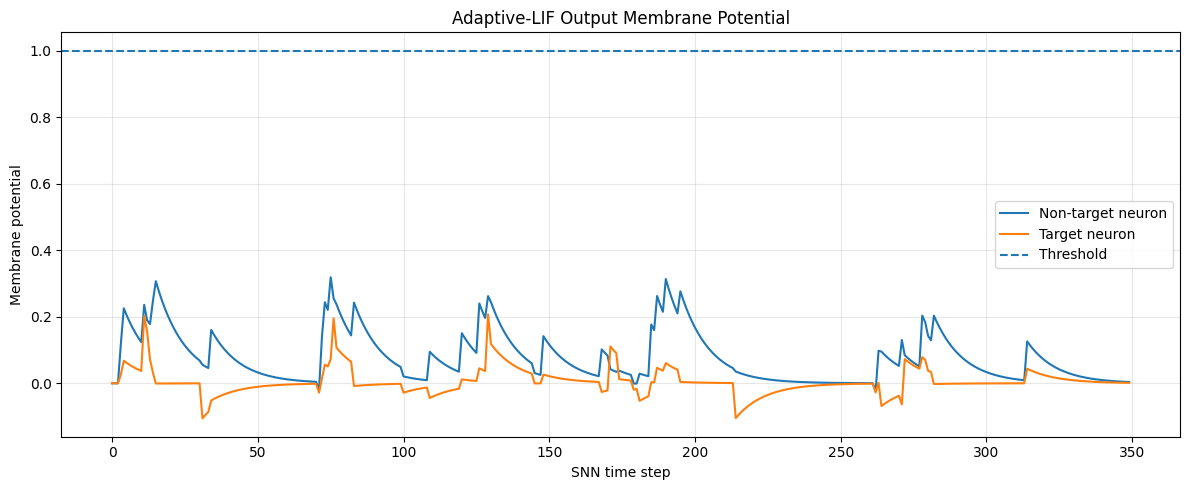


PHASE 3 FORWARD PASS COMPLETE
Predictions shape: (80,)
Hidden spike trajectory: (80, 350, 32)
Output spike trajectory: (80, 350, 2)
Membrane trajectory: (80, 350, 2)
Output spike counts: (80, 2)

Current accuracy: 87.50%

IMPORTANT:
This is NOT trained accuracy.
The weights have only been randomly initialized.
Training will be the next step.


In [20]:
# ============================================================
# PHASE 3 — ADAPTIVE-LIF SNN
# SBJ01 / S01 / BLOCK 1
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. CHECK INPUT
# ------------------------------------------------------------

print("Spike train shape:", spike_train.shape)
print("Labels shape:", y_phase1.shape)

# Expected:
# spike_train = (80, 8, 100)
# y_phase1    = (80,)


# ------------------------------------------------------------
# 2. ADAPTIVE-LIF PARAMETERS
# ------------------------------------------------------------

N_INPUTS = 8
N_HIDDEN = 32
N_OUTPUT = 2

N_STEPS = spike_train.shape[2]

dt = 1.0

tau_mem = 10.0
tau_adapt = 50.0

beta = np.exp(-dt / tau_mem)
rho = np.exp(-dt / tau_adapt)

threshold = 1.0

adaptation_strength = 0.2

learning_rate = 0.005

print("\nSNN parameters:")
print("Input neurons :", N_INPUTS)
print("Hidden neurons:", N_HIDDEN)
print("Output neurons:", N_OUTPUT)
print("Time steps    :", N_STEPS)


# ------------------------------------------------------------
# 3. INITIALIZE WEIGHTS
# ------------------------------------------------------------

rng = np.random.default_rng(42)

W_input_hidden = (
    rng.normal(
        0,
        0.1,
        (N_INPUTS, N_HIDDEN)
    )
)

W_hidden_output = (
    rng.normal(
        0,
        0.1,
        (N_HIDDEN, N_OUTPUT)
    )
)

print("\nWeight shapes:")
print("Input → Hidden :", W_input_hidden.shape)
print("Hidden → Output:", W_hidden_output.shape)


# ------------------------------------------------------------
# 4. ADAPTIVE-LIF FUNCTION
# ------------------------------------------------------------

def adaptive_lif_forward(
    spikes,
    W_in,
    W_out
):
    """
    Adaptive-LIF SNN forward pass.

    Input:
        spikes = (channels, time)

    Output:
        predicted class
        output spike trajectory
        hidden spike trajectory
    """

    n_channels = spikes.shape[0]
    n_steps = spikes.shape[1]

    # --------------------------------------------------------
    # Membrane potentials
    # --------------------------------------------------------

    v_hidden = np.zeros(N_HIDDEN)
    adaptation = np.zeros(N_HIDDEN)

    v_output = np.zeros(N_OUTPUT)

    # --------------------------------------------------------
    # Store temporal trajectories
    # --------------------------------------------------------

    hidden_spikes = np.zeros(
        (n_steps, N_HIDDEN)
    )

    output_spikes = np.zeros(
        (n_steps, N_OUTPUT)
    )

    membrane_trace = np.zeros(
        (n_steps, N_OUTPUT)
    )

    # --------------------------------------------------------
    # Run SNN through time
    # --------------------------------------------------------

    for t in range(n_steps):

        # Current input spikes
        input_t = spikes[:, t]

        # ----------------------------------------------------
        # Input → Hidden
        # ----------------------------------------------------

        hidden_current = (
            input_t @ W_in
        )

        # Adaptive-LIF membrane update
        v_hidden = (
            beta * v_hidden
            + hidden_current
            - adaptation
        )

        # Generate hidden spikes
        hidden_spike = (
            v_hidden >= threshold
        ).astype(float)

        # Reset membrane after spike
        v_hidden[
            hidden_spike == 1
        ] = 0.0

        # Update adaptation
        adaptation = (
            rho * adaptation
            + adaptation_strength * hidden_spike
        )

        # Save hidden spikes
        hidden_spikes[t] = hidden_spike

        # ----------------------------------------------------
        # Hidden → Output
        # ----------------------------------------------------

        output_current = (
            hidden_spike @ W_out
        )

        v_output = (
            beta * v_output
            + output_current
        )

        # Generate output spikes
        output_spike = (
            v_output >= threshold
        ).astype(float)

        # Reset
        v_output[
            output_spike == 1
        ] = 0.0

        # Save output activity
        output_spikes[t] = output_spike

        membrane_trace[t] = v_output

    # --------------------------------------------------------
    # Classification
    #
    # More spikes = stronger evidence
    # --------------------------------------------------------

    output_counts = output_spikes.sum(axis=0)

    predicted_class = np.argmax(
        output_counts
    )

    return (
        predicted_class,
        hidden_spikes,
        output_spikes,
        membrane_trace,
        output_counts
    )


# ------------------------------------------------------------
# 5. RUN FIRST EEG EPOCH
# ------------------------------------------------------------

epoch = 0

predicted_class, \
hidden_spikes, \
output_spikes, \
membrane_trace, \
output_counts = adaptive_lif_forward(
    spike_train[epoch],
    W_input_hidden,
    W_hidden_output
)

print("\n" + "=" * 60)
print("FIRST EPOCH")
print("=" * 60)

print("True label:", y_phase1[epoch])

print("Predicted class:", predicted_class)

print(
    "Output spike counts:",
    output_counts
)


# ------------------------------------------------------------
# 6. VISUALIZE HIDDEN SPIKE TRAJECTORY
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

for neuron in range(N_HIDDEN):

    spike_times = np.where(
        hidden_spikes[:, neuron] == 1
    )[0]

    plt.scatter(
        spike_times,
        np.full_like(
            spike_times,
            neuron
        ),
        s=12
    )

plt.xlabel("SNN time step")
plt.ylabel("Hidden neuron")

plt.title(
    "Adaptive-LIF Hidden Layer — Spike Trajectory"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. VISUALIZE OUTPUT SPIKES
# ------------------------------------------------------------

plt.figure(figsize=(12, 4))

for neuron in range(N_OUTPUT):

    spike_times = np.where(
        output_spikes[:, neuron] == 1
    )[0]

    plt.scatter(
        spike_times,
        np.full_like(
            spike_times,
            neuron
        ),
        s=80,
        label=f"Class {neuron}"
    )

plt.yticks(
    [0, 1],
    ["Non-target", "Target"]
)

plt.xlabel("SNN time step")
plt.ylabel("Output neuron")

plt.title(
    "Adaptive-LIF Output Spike Trajectory"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. VISUALIZE OUTPUT MEMBRANE POTENTIAL
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    membrane_trace[:, 0],
    label="Non-target neuron"
)

plt.plot(
    membrane_trace[:, 1],
    label="Target neuron"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Threshold"
)

plt.xlabel("SNN time step")
plt.ylabel("Membrane potential")

plt.title(
    "Adaptive-LIF Output Membrane Potential"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. RUN ALL 80 EPOCHS
# ------------------------------------------------------------

predictions = []

all_output_spikes = []

all_hidden_spikes = []

all_membrane_traces = []

all_output_counts = []


for epoch in range(
    spike_train.shape[0]
):

    result = adaptive_lif_forward(
        spike_train[epoch],
        W_input_hidden,
        W_hidden_output
    )

    pred = result[0]

    predictions.append(pred)

    all_hidden_spikes.append(
        result[1]
    )

    all_output_spikes.append(
        result[2]
    )

    all_membrane_traces.append(
        result[3]
    )

    all_output_counts.append(
        result[4]
    )


predictions = np.array(predictions)

all_hidden_spikes = np.array(
    all_hidden_spikes
)

all_output_spikes = np.array(
    all_output_spikes
)

all_membrane_traces = np.array(
    all_membrane_traces
)

all_output_counts = np.array(
    all_output_counts
)


# ------------------------------------------------------------
# 10. CHECK RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PHASE 3 FORWARD PASS COMPLETE")
print("=" * 60)

print(
    "Predictions shape:",
    predictions.shape
)

print(
    "Hidden spike trajectory:",
    all_hidden_spikes.shape
)

print(
    "Output spike trajectory:",
    all_output_spikes.shape
)

print(
    "Membrane trajectory:",
    all_membrane_traces.shape
)

print(
    "Output spike counts:",
    all_output_counts.shape
)


# ------------------------------------------------------------
# 11. TEMPORARY ACCURACY
# ------------------------------------------------------------

accuracy = np.mean(
    predictions == y_phase1
)

print(
    "\nCurrent accuracy:",
    f"{accuracy * 100:.2f}%"
)

print(
    "\nIMPORTANT:"
)

print(
    "This is NOT trained accuracy."
)

print(
    "The weights have only been randomly initialized."
)

print(
    "Training will be the next step."
)

Input EEG: (80, 8, 350)

Spike train shape: (80, 8, 350)
Expected: (80 epochs, 8 channels, 350 time steps)

Total spikes: 113797
Average spikes per epoch: 1422.4625


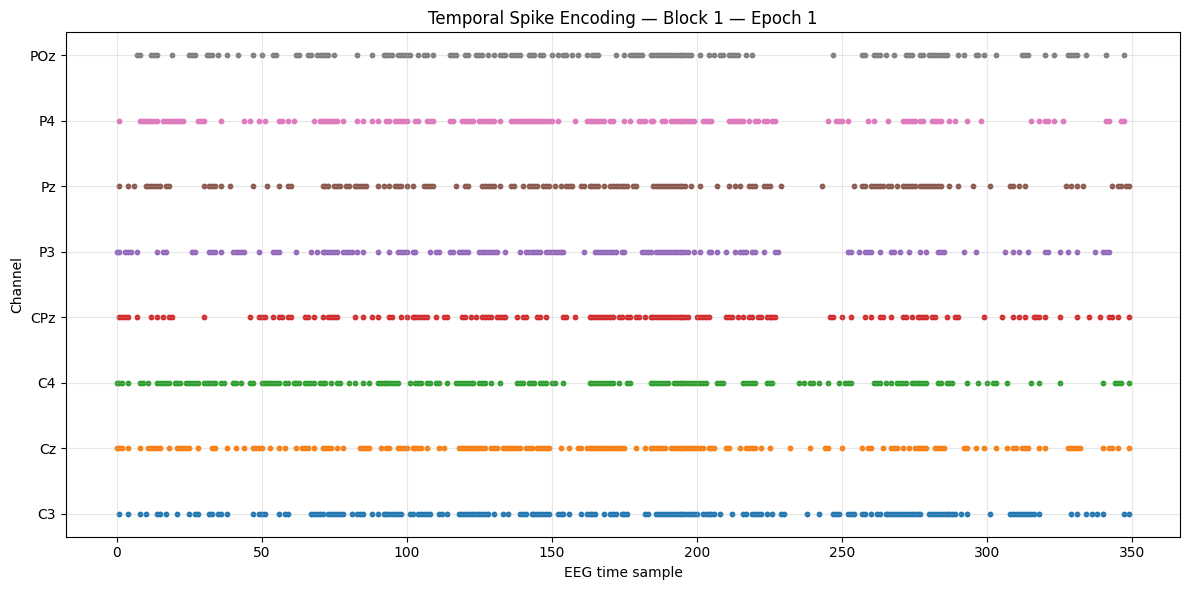

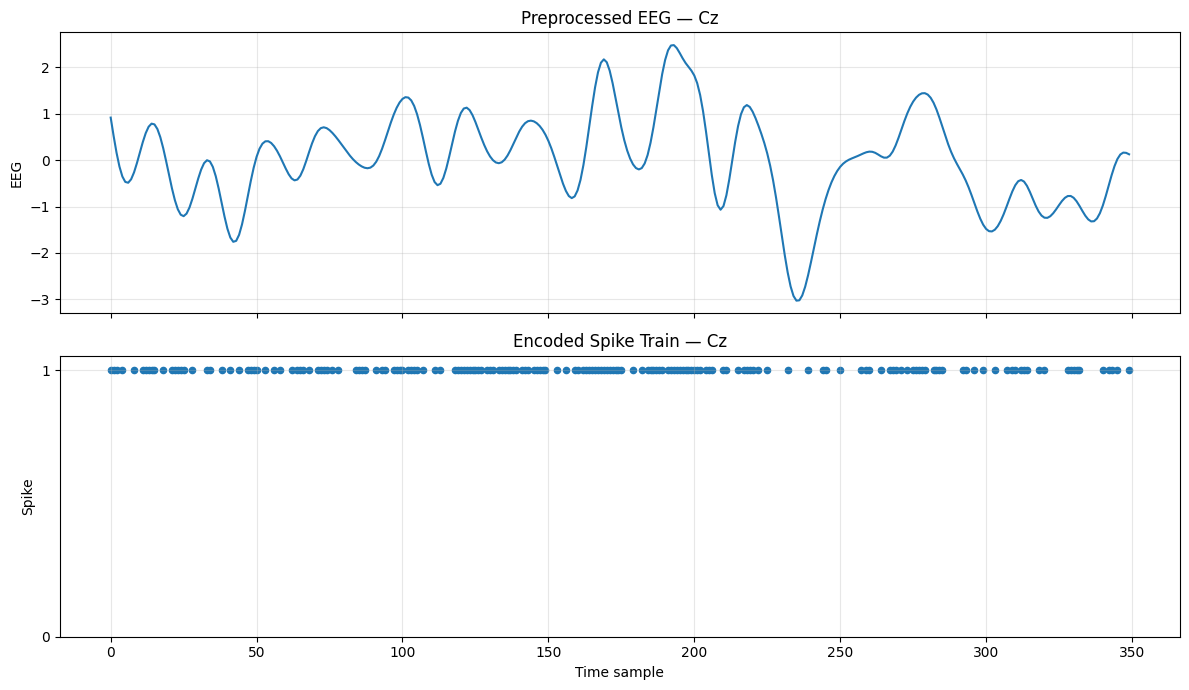


PHASE 2 CORRECTED
EEG: (80, 8, 350)
Spike train: (80, 8, 350)

Temporal information preserved: 350 samples → 350 SNN time steps


In [19]:
# ============================================================
# PHASE 2 — TEMPORAL EEG → SPIKE ENCODING
# BLOCK 1
#
# IMPORTANT:
# We preserve all 350 EEG time samples.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# INPUT
# ------------------------------------------------------------

print("Input EEG:", X_phase1.shape)

# Expected:
# (80 epochs, 8 channels, 350 samples)


# ------------------------------------------------------------
# NORMALIZE EACH CHANNEL TO [0, 1]
# ------------------------------------------------------------

X_min = X_phase1.min(axis=2, keepdims=True)
X_max = X_phase1.max(axis=2, keepdims=True)

X_norm = (
    X_phase1 - X_min
) / (
    X_max - X_min + 1e-8
)


# ------------------------------------------------------------
# TEMPORAL SPIKE ENCODING
#
# Stronger instantaneous EEG activity
# → higher probability of a spike.
#
# We preserve all 350 temporal positions.
# ------------------------------------------------------------

rng = np.random.default_rng(42)

spike_probability = X_norm

random_values = rng.random(
    X_norm.shape
)

spike_train = (
    random_values < spike_probability
).astype(np.float32)


# ------------------------------------------------------------
# CHECK SHAPE
# ------------------------------------------------------------

print("\nSpike train shape:", spike_train.shape)

print(
    "Expected:",
    "(80 epochs, 8 channels, 350 time steps)"
)


# ------------------------------------------------------------
# SPIKE COUNT
# ------------------------------------------------------------

print(
    "\nTotal spikes:",
    int(spike_train.sum())
)

print(
    "Average spikes per epoch:",
    spike_train.sum(axis=(1,2)).mean()
)


# ------------------------------------------------------------
# VISUALIZE FIRST EPOCH
# ------------------------------------------------------------

channel_names = [
    "C3", "Cz", "C4", "CPz",
    "P3", "Pz", "P4", "POz"
]

plt.figure(figsize=(12, 6))

for ch in range(8):

    spike_positions = np.where(
        spike_train[0, ch, :] == 1
    )[0]

    plt.scatter(
        spike_positions,
        np.full_like(
            spike_positions,
            ch
        ),
        s=10
    )

plt.yticks(
    range(8),
    channel_names
)

plt.xlabel("EEG time sample")
plt.ylabel("Channel")

plt.title(
    "Temporal Spike Encoding — Block 1 — Epoch 1"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# COMPARE EEG AND SPIKES FOR Cz
# ------------------------------------------------------------

cz = 1

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    sharex=True
)

# EEG
axes[0].plot(
    X_phase1[0, cz, :]
)

axes[0].set_ylabel("EEG")
axes[0].set_title(
    "Preprocessed EEG — Cz"
)

axes[0].grid(True, alpha=0.3)


# Spikes
spike_positions = np.where(
    spike_train[0, cz, :] == 1
)[0]

axes[1].scatter(
    spike_positions,
    np.ones_like(spike_positions),
    s=20
)

axes[1].set_ylabel("Spike")
axes[1].set_xlabel("Time sample")

axes[1].set_title(
    "Encoded Spike Train — Cz"
)

axes[1].set_yticks([0, 1])

axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PHASE 2 CORRECTED")
print("=" * 60)

print(
    "EEG:",
    X_phase1.shape
)

print(
    "Spike train:",
    spike_train.shape
)

print(
    "\nTemporal information preserved:",
    "350 samples → 350 SNN time steps"
)

Device: cuda
Input shape: torch.Size([80, 8, 350])
Label shape: torch.Size([80])

Training:
X: torch.Size([64, 8, 350])
Target: 8
Non-target: 56

Testing:
X: torch.Size([16, 8, 350])
Target: 2
Non-target: 14

Model:
AdaptiveLIFNet(
  (fc_in): Linear(in_features=8, out_features=32, bias=True)
  (fc_out): Linear(in_features=32, out_features=2, bias=True)
)

Class weights: [1. 7.]

TRAINING ADAPTIVE-LIF SNN
Epoch   1/100 | Loss: 8.3750 | Accuracy: 87.50%
Epoch  10/100 | Loss: 4.4377 | Accuracy: 87.50%
Epoch  20/100 | Loss: 1.7069 | Accuracy: 14.06%
Epoch  30/100 | Loss: 1.2052 | Accuracy: 26.56%
Epoch  40/100 | Loss: 0.9911 | Accuracy: 76.56%
Epoch  50/100 | Loss: 1.0278 | Accuracy: 81.25%
Epoch  60/100 | Loss: 1.0690 | Accuracy: 64.06%
Epoch  70/100 | Loss: 0.9613 | Accuracy: 59.38%
Epoch  80/100 | Loss: 0.8399 | Accuracy: 67.19%
Epoch  90/100 | Loss: 0.8178 | Accuracy: 64.06%
Epoch 100/100 | Loss: 0.6888 | Accuracy: 81.25%

TEST RESULTS
Accuracy:          87.50%
Balanced Accuracy: 50.00

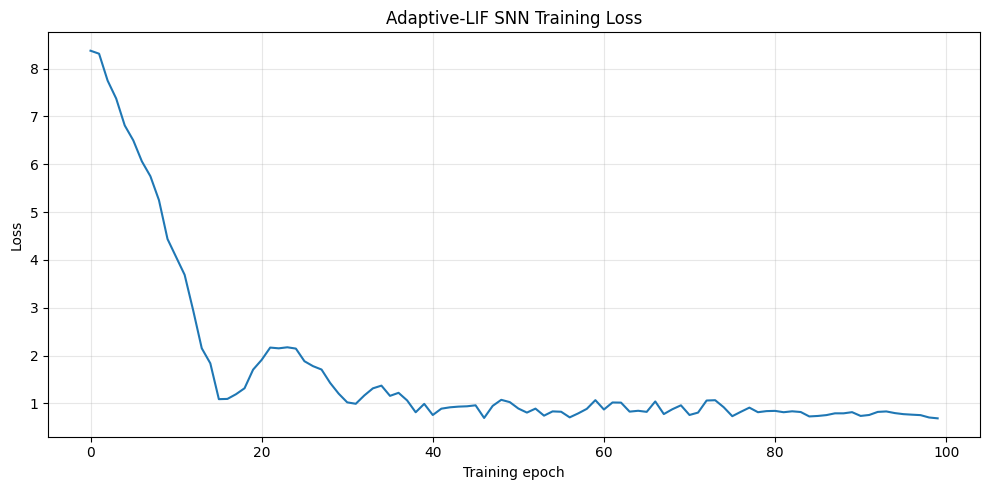

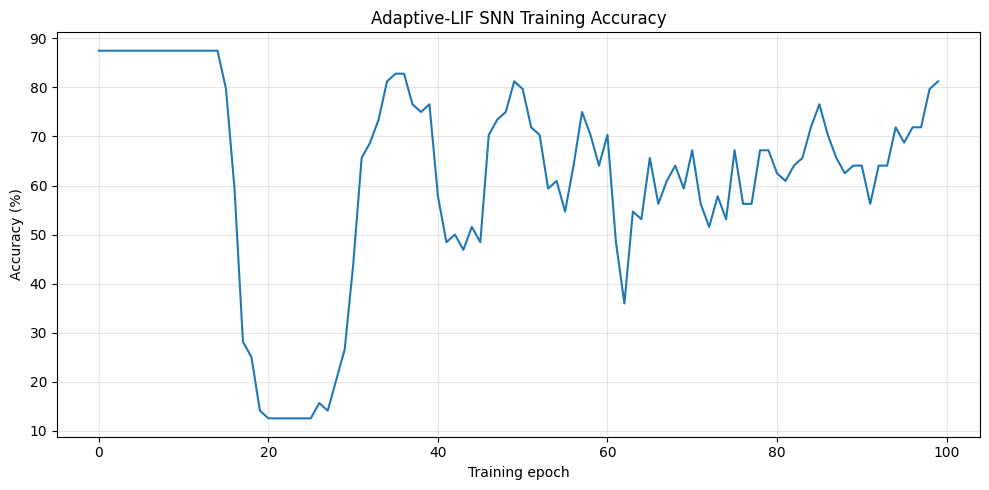


PHASE 3 COMPLETE
Hidden trajectory: (16, 350, 32)
Output trajectory: (16, 350, 2)
Membrane trajectory: (16, 350, 2)

Next stage:
SNN spike trajectory → Evidence trajectory → DDM


In [21]:
# ============================================================
# PHASE 3 — TRAINED ADAPTIVE-LIF SNN
# SBJ01 / S01 / BLOCK 1
#
# Input:
#     spike_train = (80, 8, 350)
#
# Run 1-8  -> TRAIN
# Run 9-10 -> TEST
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. SETUP
# ------------------------------------------------------------

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# ------------------------------------------------------------
# 2. DATA
# ------------------------------------------------------------

X = torch.tensor(
    spike_train,
    dtype=torch.float32
)

y = torch.tensor(
    y_phase1,
    dtype=torch.long
)

print("Input shape:", X.shape)
print("Label shape:", y.shape)

# ------------------------------------------------------------
# 3. RUN-BASED TRAIN / TEST SPLIT
#
# 10 runs × 8 events = 80 epochs
#
# Runs 1-8  = epochs 0:64
# Runs 9-10 = epochs 64:80
# ------------------------------------------------------------

train_X = X[:64]
train_y = y[:64]

test_X = X[64:]
test_y = y[64:]

print("\nTraining:")
print("X:", train_X.shape)
print("Target:", int((train_y == 1).sum()))
print("Non-target:", int((train_y == 0).sum()))

print("\nTesting:")
print("X:", test_X.shape)
print("Target:", int((test_y == 1).sum()))
print("Non-target:", int((test_y == 0).sum()))


# ------------------------------------------------------------
# 4. SURROGATE SPIKE FUNCTION
# ------------------------------------------------------------

class SpikeFunction(torch.autograd.Function):

    @staticmethod
    def forward(ctx, membrane):

        ctx.save_for_backward(membrane)

        return (membrane >= 1.0).float()

    @staticmethod
    def backward(ctx, grad_output):

        membrane, = ctx.saved_tensors

        # Surrogate gradient
        gradient = (
            1.0 /
            (
                1.0 +
                torch.abs(
                    membrane - 1.0
                )
            ) ** 2
        )

        return grad_output * gradient


spike_fn = SpikeFunction.apply


# ------------------------------------------------------------
# 5. ADAPTIVE-LIF NETWORK
# ------------------------------------------------------------

class AdaptiveLIFNet(nn.Module):

    def __init__(
        self,
        input_size=8,
        hidden_size=32,
        output_size=2
    ):

        super().__init__()

        self.hidden_size = hidden_size

        self.fc_in = nn.Linear(
            input_size,
            hidden_size
        )

        self.fc_out = nn.Linear(
            hidden_size,
            output_size
        )

        # LIF parameters
        self.beta = 0.90
        self.rho = 0.95

        self.adaptation_strength = 0.20

    def forward(self, x):

        # x:
        # batch × channels × time

        batch_size = x.shape[0]
        time_steps = x.shape[2]

        v = torch.zeros(
            batch_size,
            self.hidden_size,
            device=x.device
        )

        adaptation = torch.zeros(
            batch_size,
            self.hidden_size,
            device=x.device
        )

        v_out = torch.zeros(
            batch_size,
            2,
            device=x.device
        )

        hidden_trace = []
        output_trace = []
        membrane_trace = []

        # ----------------------------------------------------
        # TEMPORAL SNN PROCESSING
        # ----------------------------------------------------

        for t in range(time_steps):

            # Input at time t
            x_t = x[:, :, t]

            # ------------------------------------------------
            # INPUT → HIDDEN
            # ------------------------------------------------

            current = self.fc_in(x_t)

            # Adaptive membrane
            v = (
                self.beta * v
                + current
                - adaptation
            )

            # Hidden spike
            s = spike_fn(v)

            # Reset
            v = v * (1.0 - s)

            # Adaptation
            adaptation = (
                self.rho * adaptation
                +
                self.adaptation_strength * s
            )

            # ------------------------------------------------
            # HIDDEN → OUTPUT
            # ------------------------------------------------

            output_current = self.fc_out(s)

            v_out = (
                self.beta * v_out
                +
                output_current
            )

            output_spike = spike_fn(v_out)

            # Reset output
            v_out = (
                v_out *
                (1.0 - output_spike)
            )

            # ------------------------------------------------
            # SAVE TEMPORAL ACTIVITY
            # ------------------------------------------------

            hidden_trace.append(s)
            output_trace.append(output_spike)
            membrane_trace.append(v_out)

        # ----------------------------------------------------
        # (time, batch, neuron)
        # →
        # (batch, time, neuron)
        # ----------------------------------------------------

        hidden_trace = torch.stack(
            hidden_trace,
            dim=1
        )

        output_trace = torch.stack(
            output_trace,
            dim=1
        )

        membrane_trace = torch.stack(
            membrane_trace,
            dim=1
        )

        # ----------------------------------------------------
        # OUTPUT SPIKE COUNT
        # ----------------------------------------------------

        output_counts = output_trace.sum(
            dim=1
        )

        return (
            output_counts,
            hidden_trace,
            output_trace,
            membrane_trace
        )


# ------------------------------------------------------------
# 6. CREATE MODEL
# ------------------------------------------------------------

model = AdaptiveLIFNet(
    input_size=8,
    hidden_size=32,
    output_size=2
).to(device)

print("\nModel:")
print(model)


# ------------------------------------------------------------
# 7. CLASS-WEIGHTED LOSS
#
# Important because:
#
# Target     = 10
# Non-target = 70
# ------------------------------------------------------------

n_non_target = (train_y == 0).sum().item()
n_target = (train_y == 1).sum().item()

weight_non_target = 1.0
weight_target = (
    n_non_target /
    max(n_target, 1)
)

class_weights = torch.tensor(
    [
        weight_non_target,
        weight_target
    ],
    dtype=torch.float32,
    device=device
)

print(
    "\nClass weights:",
    class_weights.cpu().numpy()
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ------------------------------------------------------------
# 8. OPTIMIZER
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


# ------------------------------------------------------------
# 9. TRAIN
# ------------------------------------------------------------

train_X = train_X.to(device)
train_y = train_y.to(device)

loss_history = []
accuracy_history = []

N_EPOCHS = 100

print("\n" + "=" * 60)
print("TRAINING ADAPTIVE-LIF SNN")
print("=" * 60)

for epoch in range(N_EPOCHS):

    model.train()

    optimizer.zero_grad()

    output_counts, _, _, _ = model(
        train_X
    )

    loss = criterion(
        output_counts,
        train_y
    )

    loss.backward()

    # Prevent exploding gradients
    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()

    # --------------------------------------------------------
    # Training prediction
    # --------------------------------------------------------

    prediction = torch.argmax(
        output_counts,
        dim=1
    )

    accuracy = (
        prediction == train_y
    ).float().mean()

    loss_history.append(
        loss.item()
    )

    accuracy_history.append(
        accuracy.item()
    )

    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
    ):

        print(
            f"Epoch {epoch+1:3d}/{N_EPOCHS} | "
            f"Loss: {loss.item():.4f} | "
            f"Accuracy: {accuracy.item()*100:.2f}%"
        )


# ------------------------------------------------------------
# 10. TEST
# ------------------------------------------------------------

model.eval()

test_X_device = test_X.to(device)
test_y_device = test_y.to(device)

with torch.no_grad():

    test_counts, \
    test_hidden_trace, \
    test_output_trace, \
    test_membrane_trace = model(
        test_X_device
    )

    test_predictions = torch.argmax(
        test_counts,
        dim=1
    )


# ------------------------------------------------------------
# 11. METRICS
# ------------------------------------------------------------

true = test_y_device.cpu().numpy()
pred = test_predictions.cpu().numpy()

tp = np.sum(
    (true == 1) & (pred == 1)
)

tn = np.sum(
    (true == 0) & (pred == 0)
)

fp = np.sum(
    (true == 0) & (pred == 1)
)

fn = np.sum(
    (true == 1) & (pred == 0)
)

accuracy = (
    (tp + tn) /
    max(len(true), 1)
)

precision = (
    tp /
    max(tp + fp, 1)
)

recall = (
    tp /
    max(tp + fn, 1)
)

f1 = (
    2 * precision * recall /
    max(precision + recall, 1e-8)
)

balanced_accuracy = (
    0.5 *
    (
        tn / max(tn + fp, 1)
        +
        tp / max(tp + fn, 1)
    )
)


# ------------------------------------------------------------
# 12. RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TEST RESULTS")
print("=" * 60)

print(f"Accuracy:          {accuracy*100:.2f}%")
print(f"Balanced Accuracy: {balanced_accuracy*100:.2f}%")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1:                {f1:.4f}")

print("\nConfusion matrix:")
print(
    f"TN = {tn}   FP = {fp}"
)

print(
    f"FN = {fn}   TP = {tp}"
)


# ------------------------------------------------------------
# 13. OUTPUT SPIKE COUNTS
# ------------------------------------------------------------

print("\nTest output spike counts:")

print(
    test_counts.cpu().numpy()
)


# ------------------------------------------------------------
# 14. PLOT LOSS
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    loss_history
)

plt.xlabel("Training epoch")
plt.ylabel("Loss")

plt.title(
    "Adaptive-LIF SNN Training Loss"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 15. PLOT ACCURACY
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    np.array(accuracy_history) * 100
)

plt.xlabel("Training epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Adaptive-LIF SNN Training Accuracy"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. SAVE TEMPORAL TRAJECTORIES
# ------------------------------------------------------------

trained_hidden_spikes = (
    test_hidden_trace
    .cpu()
    .numpy()
)

trained_output_spikes = (
    test_output_trace
    .cpu()
    .numpy()
)

trained_membrane = (
    test_membrane_trace
    .cpu()
    .numpy()
)

print("\n" + "=" * 60)
print("PHASE 3 COMPLETE")
print("=" * 60)

print(
    "Hidden trajectory:",
    trained_hidden_spikes.shape
)

print(
    "Output trajectory:",
    trained_output_spikes.shape
)

print(
    "Membrane trajectory:",
    trained_membrane.shape
)

print("\nNext stage:")
print("SNN spike trajectory → Evidence trajectory → DDM")

Device: cuda
Full X: torch.Size([80, 8, 350])
Full y: torch.Size([80])

TRAIN
Shape: torch.Size([48, 8, 350])
Target: 6
Non-target: 42

VALIDATION
Shape: torch.Size([16, 8, 350])
Target: 2
Non-target: 14

TEST
Shape: torch.Size([16, 8, 350])
Target: 2
Non-target: 14

Model:
AdaptiveLIFNet(
  (fc_in): Linear(in_features=8, out_features=32, bias=True)
  (fc_out): Linear(in_features=32, out_features=2, bias=True)
)

Class weights: [0.5714286 4.       ]

TRAINING
Epoch   1/200 | Train Loss: 7.3333 | Train Acc: 87.50% | Val Loss: 7.7500 | Val Acc: 87.50%
Epoch  10/200 | Train Loss: 5.5834 | Train Acc: 87.50% | Val Loss: 6.2500 | Val Acc: 87.50%
Epoch  20/200 | Train Loss: 3.4193 | Train Acc: 87.50% | Val Loss: 4.0014 | Val Acc: 87.50%
Epoch  30/200 | Train Loss: 1.2355 | Train Acc: 81.25% | Val Loss: 0.6622 | Val Acc: 81.25%
Epoch  40/200 | Train Loss: 0.8741 | Train Acc: 37.50% | Val Loss: 0.9206 | Val Acc: 31.25%
Epoch  50/200 | Train Loss: 0.8864 | Train Acc: 79.17% | Val Loss: 0.6305 | 

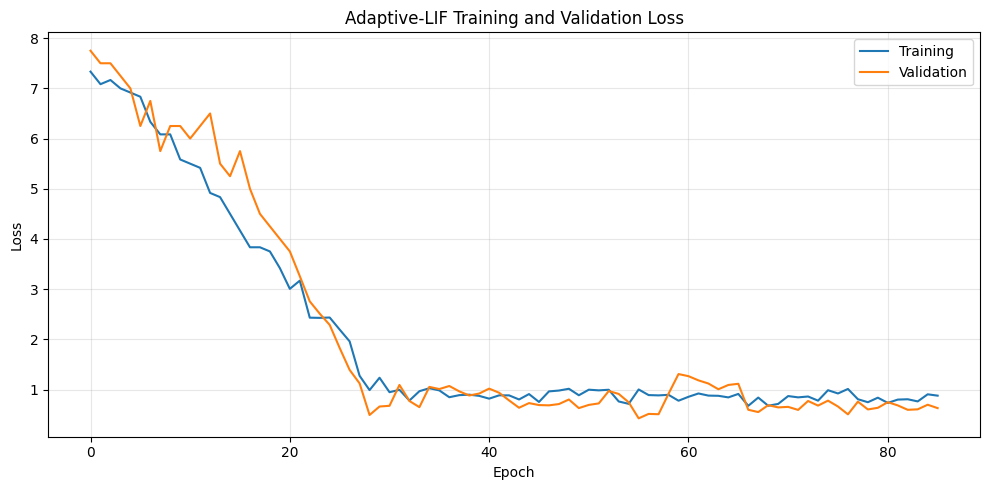

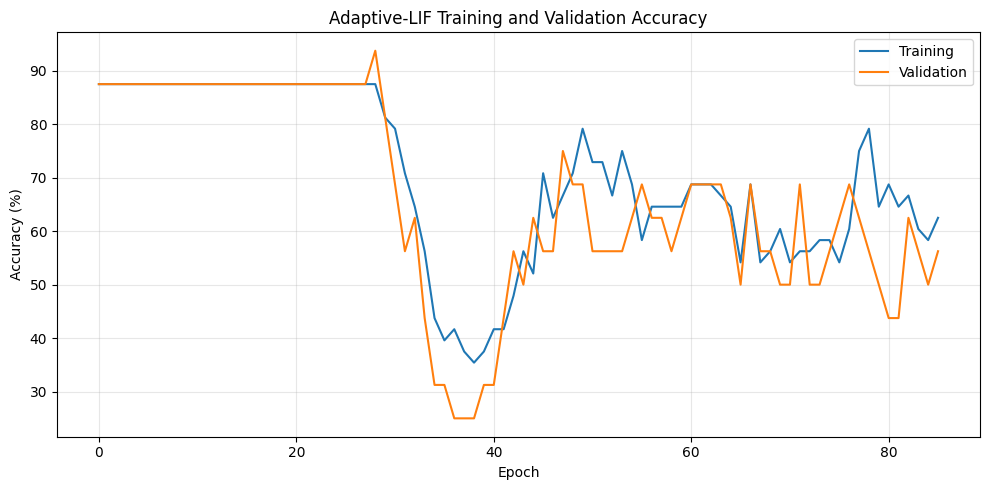

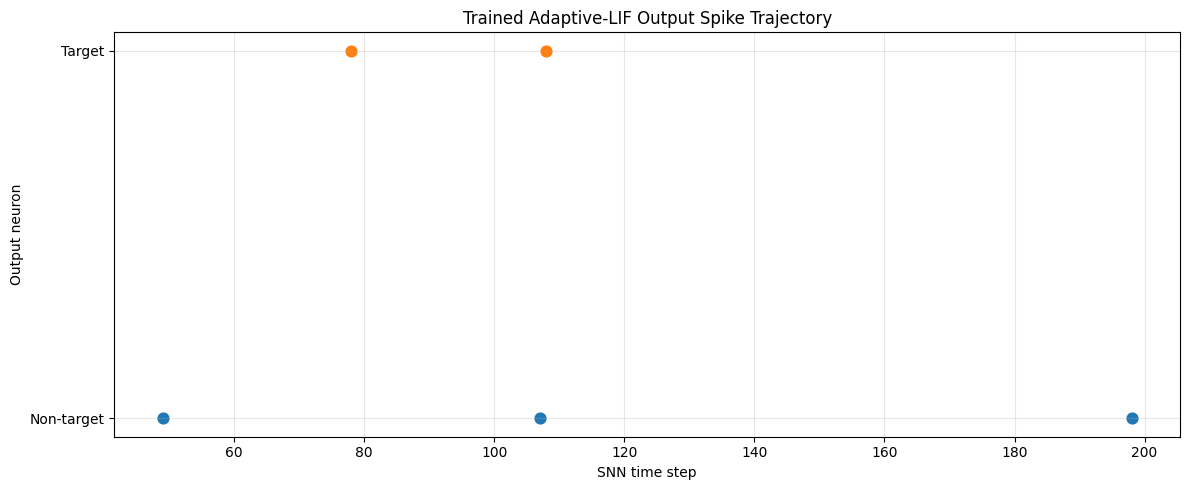


PHASE 3 TRAINING FINISHED
The SNN now produces:
1. Target/non-target prediction
2. Hidden-layer spike trajectory
3. Output spike trajectory
4. Output membrane trajectory

These trajectories are the input for the next evidence-accumulation stage.


In [22]:
# ============================================================
# PHASE 3 — IMPROVED ADAPTIVE-LIF SNN TRAINING
# BLOCK 1
#
# Runs 1-6  -> TRAIN
# Runs 7-8  -> VALIDATION
# Runs 9-10 -> TEST
#
# Input:
#     spike_train = (80, 8, 350)
# ============================================================

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. REPRODUCIBILITY
# ------------------------------------------------------------

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ------------------------------------------------------------
# 2. DATA
# ------------------------------------------------------------

X = torch.tensor(
    spike_train,
    dtype=torch.float32
)

y = torch.tensor(
    y_phase1,
    dtype=torch.long
)

print("Full X:", X.shape)
print("Full y:", y.shape)


# ------------------------------------------------------------
# 3. SPLIT BY RUN
#
# 8 trials per run
#
# Run 1-6  = 48 trials
# Run 7-8  = 16 trials
# Run 9-10 = 16 trials
# ------------------------------------------------------------

train_X = X[:48]
train_y = y[:48]

val_X = X[48:64]
val_y = y[48:64]

test_X = X[64:80]
test_y = y[64:80]


print("\nTRAIN")
print("Shape:", train_X.shape)
print("Target:", int((train_y == 1).sum()))
print("Non-target:", int((train_y == 0).sum()))

print("\nVALIDATION")
print("Shape:", val_X.shape)
print("Target:", int((val_y == 1).sum()))
print("Non-target:", int((val_y == 0).sum()))

print("\nTEST")
print("Shape:", test_X.shape)
print("Target:", int((test_y == 1).sum()))
print("Non-target:", int((test_y == 0).sum()))


# ------------------------------------------------------------
# 4. SURROGATE SPIKE FUNCTION
# ------------------------------------------------------------

class SpikeFunction(torch.autograd.Function):

    @staticmethod
    def forward(ctx, membrane):

        ctx.save_for_backward(membrane)

        return (membrane >= 1.0).float()

    @staticmethod
    def backward(ctx, grad_output):

        membrane, = ctx.saved_tensors

        # Smooth surrogate derivative
        gradient = (
            1.0 /
            (
                1.0 +
                torch.abs(membrane - 1.0)
            ) ** 2
        )

        return grad_output * gradient


spike_fn = SpikeFunction.apply


# ------------------------------------------------------------
# 5. ADAPTIVE-LIF NETWORK
# ------------------------------------------------------------

class AdaptiveLIFNet(nn.Module):

    def __init__(
        self,
        input_size=8,
        hidden_size=32,
        output_size=2
    ):

        super().__init__()

        self.hidden_size = hidden_size

        self.fc_in = nn.Linear(
            input_size,
            hidden_size
        )

        self.fc_out = nn.Linear(
            hidden_size,
            output_size
        )

        # LIF decay
        self.beta = 0.90

        # Adaptation decay
        self.rho = 0.95

        # Adaptation strength
        self.adaptation_strength = 0.15

        # Threshold
        self.threshold = 1.0


    def forward(self, x):

        batch_size = x.shape[0]
        time_steps = x.shape[2]

        # ----------------------------------------------------
        # Hidden state
        # ----------------------------------------------------

        v = torch.zeros(
            batch_size,
            self.hidden_size,
            device=x.device
        )

        adaptation = torch.zeros(
            batch_size,
            self.hidden_size,
            device=x.device
        )

        # ----------------------------------------------------
        # Output state
        # ----------------------------------------------------

        v_out = torch.zeros(
            batch_size,
            2,
            device=x.device
        )

        # ----------------------------------------------------
        # Temporal trajectories
        # ----------------------------------------------------

        hidden_trace = []
        output_trace = []
        membrane_trace = []

        # ----------------------------------------------------
        # PROCESS THROUGH TIME
        # ----------------------------------------------------

        for t in range(time_steps):

            # Input spike at time t
            x_t = x[:, :, t]

            # ------------------------------------------------
            # Input → Hidden
            # ------------------------------------------------

            current = self.fc_in(x_t)

            v = (
                self.beta * v
                +
                current
                -
                adaptation
            )

            hidden_spikes = spike_fn(v)

            # Reset after spike
            v = v * (1.0 - hidden_spikes)

            # Adaptation
            adaptation = (
                self.rho * adaptation
                +
                self.adaptation_strength *
                hidden_spikes
            )

            # ------------------------------------------------
            # Hidden → Output
            # ------------------------------------------------

            output_current = self.fc_out(
                hidden_spikes
            )

            v_out = (
                self.beta * v_out
                +
                output_current
            )

            output_spikes = spike_fn(
                v_out
            )

            # Reset
            v_out = (
                v_out *
                (1.0 - output_spikes)
            )

            # ------------------------------------------------
            # SAVE TRAJECTORIES
            # ------------------------------------------------

            hidden_trace.append(
                hidden_spikes
            )

            output_trace.append(
                output_spikes
            )

            membrane_trace.append(
                v_out
            )

        # ----------------------------------------------------
        # Convert to:
        #
        # batch × time × neurons
        # ----------------------------------------------------

        hidden_trace = torch.stack(
            hidden_trace,
            dim=1
        )

        output_trace = torch.stack(
            output_trace,
            dim=1
        )

        membrane_trace = torch.stack(
            membrane_trace,
            dim=1
        )

        # ----------------------------------------------------
        # Total output spikes
        # ----------------------------------------------------

        spike_counts = output_trace.sum(
            dim=1
        )

        return (
            spike_counts,
            hidden_trace,
            output_trace,
            membrane_trace
        )


# ------------------------------------------------------------
# 6. CREATE MODEL
# ------------------------------------------------------------

model = AdaptiveLIFNet(
    input_size=8,
    hidden_size=32,
    output_size=2
).to(device)

print("\nModel:")
print(model)


# ------------------------------------------------------------
# 7. CLASS WEIGHTS
# ------------------------------------------------------------

n_non_target = int(
    (train_y == 0).sum()
)

n_target = int(
    (train_y == 1).sum()
)

# Balanced weighting
total = n_non_target + n_target

weight_non_target = (
    total / (2 * n_non_target)
)

weight_target = (
    total / (2 * n_target)
)

class_weights = torch.tensor(
    [
        weight_non_target,
        weight_target
    ],
    dtype=torch.float32,
    device=device
)

print(
    "\nClass weights:",
    class_weights.cpu().numpy()
)


# ------------------------------------------------------------
# 8. LOSS + OPTIMIZER
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)


# ------------------------------------------------------------
# 9. MOVE DATA TO DEVICE
# ------------------------------------------------------------

train_X = train_X.to(device)
train_y = train_y.to(device)

val_X = val_X.to(device)
val_y = val_y.to(device)

test_X = test_X.to(device)
test_y = test_y.to(device)


# ------------------------------------------------------------
# 10. TRAINING
# ------------------------------------------------------------

N_EPOCHS = 200

best_val_loss = float("inf")

best_state = None

patience = 30

patience_counter = 0

train_losses = []
val_losses = []

train_accs = []
val_accs = []


print("\n" + "=" * 60)
print("TRAINING")
print("=" * 60)


for epoch in range(N_EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    optimizer.zero_grad()

    train_counts, _, _, _ = model(
        train_X
    )

    train_loss = criterion(
        train_counts,
        train_y
    )

    train_loss.backward()

    # Prevent exploding gradients
    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()


    # --------------------------------------------------------
    # Training accuracy
    # --------------------------------------------------------

    train_pred = torch.argmax(
        train_counts,
        dim=1
    )

    train_acc = (
        train_pred == train_y
    ).float().mean()


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    with torch.no_grad():

        val_counts, _, _, _ = model(
            val_X
        )

        val_loss = criterion(
            val_counts,
            val_y
        )

        val_pred = torch.argmax(
            val_counts,
            dim=1
        )

        val_acc = (
            val_pred == val_y
        ).float().mean()


    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    train_losses.append(
        train_loss.item()
    )

    val_losses.append(
        val_loss.item()
    )

    train_accs.append(
        train_acc.item()
    )

    val_accs.append(
        val_acc.item()
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if val_loss.item() < best_val_loss:

        best_val_loss = val_loss.item()

        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1


    if (
        epoch == 0
        or (epoch + 1) % 10 == 0
    ):

        print(
            f"Epoch {epoch+1:3d}/{N_EPOCHS} | "
            f"Train Loss: {train_loss.item():.4f} | "
            f"Train Acc: {train_acc.item()*100:.2f}% | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Val Acc: {val_acc.item()*100:.2f}%"
        )


    if patience_counter >= patience:

        print(
            f"\nEarly stopping at epoch "
            f"{epoch + 1}"
        )

        break


# ------------------------------------------------------------
# 11. RESTORE BEST MODEL
# ------------------------------------------------------------

if best_state is not None:

    model.load_state_dict(
        best_state
    )


# ------------------------------------------------------------
# 12. FINAL TEST
# ------------------------------------------------------------

model.eval()

with torch.no_grad():

    test_counts, \
    test_hidden_trace, \
    test_output_trace, \
    test_membrane_trace = model(
        test_X
    )

    test_predictions = torch.argmax(
        test_counts,
        dim=1
    )


# ------------------------------------------------------------
# 13. CONVERT TO NUMPY
# ------------------------------------------------------------

true = (
    test_y
    .cpu()
    .numpy()
)

pred = (
    test_predictions
    .cpu()
    .numpy()
)


# ------------------------------------------------------------
# 14. CONFUSION MATRIX
# ------------------------------------------------------------

tp = np.sum(
    (true == 1) &
    (pred == 1)
)

tn = np.sum(
    (true == 0) &
    (pred == 0)
)

fp = np.sum(
    (true == 0) &
    (pred == 1)
)

fn = np.sum(
    (true == 1) &
    (pred == 0)
)


# ------------------------------------------------------------
# 15. METRICS
# ------------------------------------------------------------

accuracy = (
    tp + tn
) / max(len(true), 1)

target_recall = (
    tp /
    max(tp + fn, 1)
)

target_precision = (
    tp /
    max(tp + fp, 1)
)

target_f1 = (
    2 *
    target_precision *
    target_recall /
    max(
        target_precision +
        target_recall,
        1e-8
    )
)

non_target_recall = (
    tn /
    max(tn + fp, 1)
)

balanced_accuracy = (
    target_recall +
    non_target_recall
) / 2


# ------------------------------------------------------------
# 16. RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy:          {accuracy*100:.2f}%"
)

print(
    f"Balanced Accuracy: {balanced_accuracy*100:.2f}%"
)

print(
    f"Target Precision:  {target_precision:.4f}"
)

print(
    f"Target Recall:     {target_recall:.4f}"
)

print(
    f"Target F1:         {target_f1:.4f}"
)

print("\nConfusion Matrix:")

print(
    f"TN = {tn}   FP = {fp}"
)

print(
    f"FN = {fn}   TP = {tp}"
)

print(
    "\nPredictions:",
    pred
)

print(
    "True labels:",
    true
)


# ------------------------------------------------------------
# 17. OUTPUT SPIKE COUNTS
# ------------------------------------------------------------

print("\nOutput spike counts:")

print(
    test_counts
    .cpu()
    .numpy()
)


# ------------------------------------------------------------
# 18. SAVE TEMPORAL TRAJECTORIES
# ------------------------------------------------------------

trained_hidden_spikes = (
    test_hidden_trace
    .cpu()
    .numpy()
)

trained_output_spikes = (
    test_output_trace
    .cpu()
    .numpy()
)

trained_membrane = (
    test_membrane_trace
    .cpu()
    .numpy()
)


print("\nTemporal trajectories:")

print(
    "Hidden:",
    trained_hidden_spikes.shape
)

print(
    "Output:",
    trained_output_spikes.shape
)

print(
    "Membrane:",
    trained_membrane.shape
)


# ------------------------------------------------------------
# 19. TRAINING / VALIDATION LOSS
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Training"
)

plt.plot(
    val_losses,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Adaptive-LIF Training and Validation Loss"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 20. TRAINING / VALIDATION ACCURACY
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    np.array(train_accs) * 100,
    label="Training"
)

plt.plot(
    np.array(val_accs) * 100,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Adaptive-LIF Training and Validation Accuracy"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 21. OUTPUT SPIKE TRAJECTORY
# ------------------------------------------------------------

first_output = (
    trained_output_spikes[0]
)

plt.figure(figsize=(12, 5))

for neuron in range(2):

    positions = np.where(
        first_output[:, neuron] == 1
    )[0]

    plt.scatter(
        positions,
        np.full_like(
            positions,
            neuron
        ),
        s=60
    )

plt.yticks(
    [0, 1],
    ["Non-target", "Target"]
)

plt.xlabel("SNN time step")

plt.ylabel("Output neuron")

plt.title(
    "Trained Adaptive-LIF Output Spike Trajectory"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 22. FINISH
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PHASE 3 TRAINING FINISHED")
print("=" * 60)

print(
    "The SNN now produces:"
)

print(
    "1. Target/non-target prediction"
)

print(
    "2. Hidden-layer spike trajectory"
)

print(
    "3. Output spike trajectory"
)

print(
    "4. Output membrane trajectory"
)

print(
    "\nThese trajectories are the input"
    " for the next evidence-accumulation stage."
)